[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train RF-DETR Segmentation on a Custom Dataset

---

[![hf space](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Spaces-blue)](https://huggingface.co/spaces/SkalskiP/RF-DETR)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-finetune-rf-detr-on-detection-dataset.ipynb)
[![roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/rf-detr)
[![code](https://badges.aleen42.com/src/github.svg)](https://github.com/roboflow/rf-detr)

RF-DETR Segmentation is a new real-time instance segmentation model from Roboflow. Licensed under Apache 2.0, RF-DETR Segmentation outperforms the largest YOLO11 on the Microsoft COCO Segmentation benchmark, delivering 3x higher speed and accuracy. It is the first DETR-based segmentation model to exceed 30 FPS on a T4 GPU. With an end-to-end latency of 5.6 ms, it reaches over 170 FPS.

> **🚀 Running on NVIDIA Brev:** This notebook is pre-configured to run on an A100 GPU. No setup required - just run the cells below.

![rf-detr-segmentation-previev-coco-3](https://storage.googleapis.com/com-roboflow-marketing/notebooks/rf-detr-segmentation-previev-coco-3.png)

## Environment setup

### Configure API Key

To fine-tune RF-DETR, you need to provide your Roboflow API key:

1. Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy` to copy your private API key.
2. Run the cell below and paste your API key when prompted (input will be hidden).

In [ ]:
import os
from getpass import getpass

os.environ["ROBOFLOW_API_KEY"] = getpass("Enter your Roboflow API key: ")

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. This Launchable runs on an A100 GPU - running the cell below should confirm your GPU is available and ready.

In [ ]:
!nvidia-smi

Fri Oct  3 10:34:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   40C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install dependencies

Installs RF-DETR version 1.3.0 or higher (which includes the Segmentation Preview available in the Medium checkpoint), along with Supervision for visualizations and Roboflow for pulling datasets and uploading models to the Roboflow platform.

In [ ]:
!pip install -q rfdetr==1.3.0 supervision==0.26.1 roboflow==1.2.10

### Download example data

Downloads example images for testing. You can use these or replace them with your own images.

In [ ]:
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

## Inference with Pre-trained COCO Model

Runs inference on an example image using the RF-DETR Segmentation Preview model (Medium checkpoint trained on COCO).

In [ ]:
from rfdetr import RFDETRSegPreview
from rfdetr.util.coco_classes import COCO_CLASSES

model = RFDETRSegPreview()
model.optimize_for_inference()

In [ ]:
import supervision as sv
from PIL import Image

def annotate(image: Image.Image, detections: sv.Detections, classes: dict[int, str]) -> Image.Image:
    color = sv.ColorPalette.from_hex([
        "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
        "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
    ])
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    mask_annotator = sv.MaskAnnotator(color=color)
    polygon_annotator = sv.PolygonAnnotator(color=sv.Color.WHITE)
    label_annotator = sv.LabelAnnotator(
        color=color,
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        text_position=sv.Position.CENTER_OF_MASS
    )

    labels = [
        f"{classes.get(class_id, 'unknown')} {confidence:.2f}"
        for class_id, confidence in zip(detections.class_id, detections.confidence)
    ]

    out = image.copy()
    out = mask_annotator.annotate(out, detections)
    out = polygon_annotator.annotate(out, detections)
    out = label_annotator.annotate(out, detections, labels)
    out.thumbnail((1000, 1000))
    return out

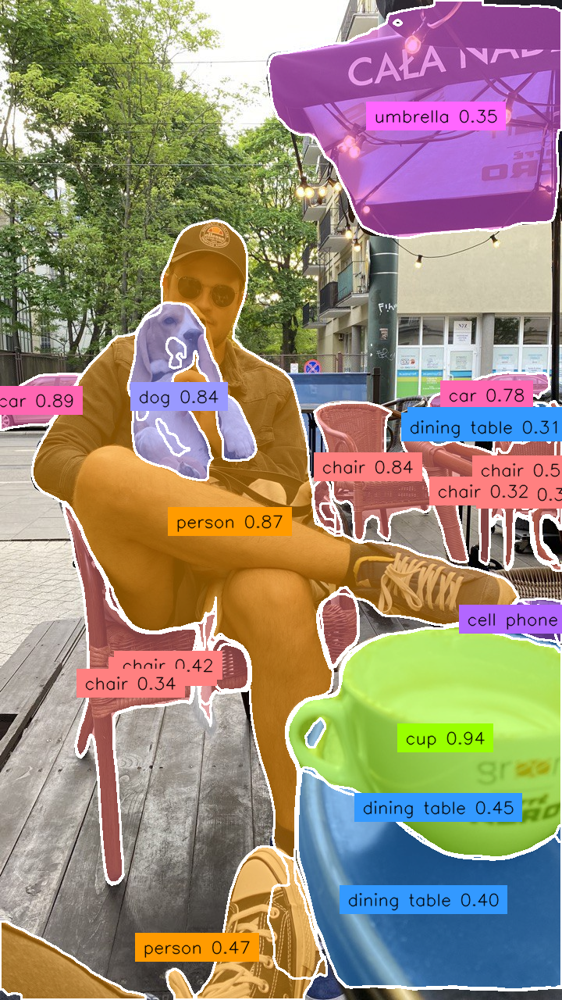

In [ ]:
image = Image.open("dog-3.jpeg")

detections = model.predict(image, threshold=0.3)

annotated_image = annotate(image, detections, classes=COCO_CLASSES)
annotated_image

## Download Dataset from Roboflow Universe

RF-DETR expects the dataset to be in COCO format. Divide your dataset into three subdirectories: `train`, `valid`, and `test`. Each subdirectory should contain its own `_annotations.coco.json` file that holds the annotations for that particular split, along with the corresponding image files. Below is an example of the directory structure:

```
dataset/
├── train/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
├── valid/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
└── test/
    ├── _annotations.coco.json
    ├── image1.jpg
    ├── image2.jpg
    └── ... (other image files)
```

[Roboflow](https://roboflow.com/annotate) allows you to create segmentation datasets from scratch or convert existing datasets from formats like YOLO, and then export them in COCO JSON format for training. You can also explore [Roboflow Universe](https://universe.roboflow.com/) to find pre-labeled segmentation datasets for a range of use cases.

In [ ]:
from roboflow import download_dataset

dataset = download_dataset("https://universe.roboflow.com/roboflow-jvuqo/creacks-eapny/4", "coco")

loading Roboflow workspace...
loading Roboflow project...
Exporting format coco in progress : 85.0%
Version export complete for coco format



Extracting Dataset Version Zip to creacks-4 in coco:: 100%|██████████| 4036/4036 [00:00<00:00, 5401.56it/s]


## Train RF-DETR on custom dataset

### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

This Launchable runs on an A100 GPU (80GB VRAM), so we use `batch_size=16` and `grad_accum_steps=1` for optimal training speed. These settings are already configured in the cell below - just run it to start training.

> **Note:** If you're running this notebook on different hardware, adjust those values below. For example, on a less powerful T4, use `batch_size=4` and `grad_accum_steps=4`. 

In [ ]:
from rfdetr import RFDETRSegPreview

model = RFDETRSegPreview()

model.train(dataset_dir=dataset.location, epochs=5, batch_size=16, grad_accum_steps=1)

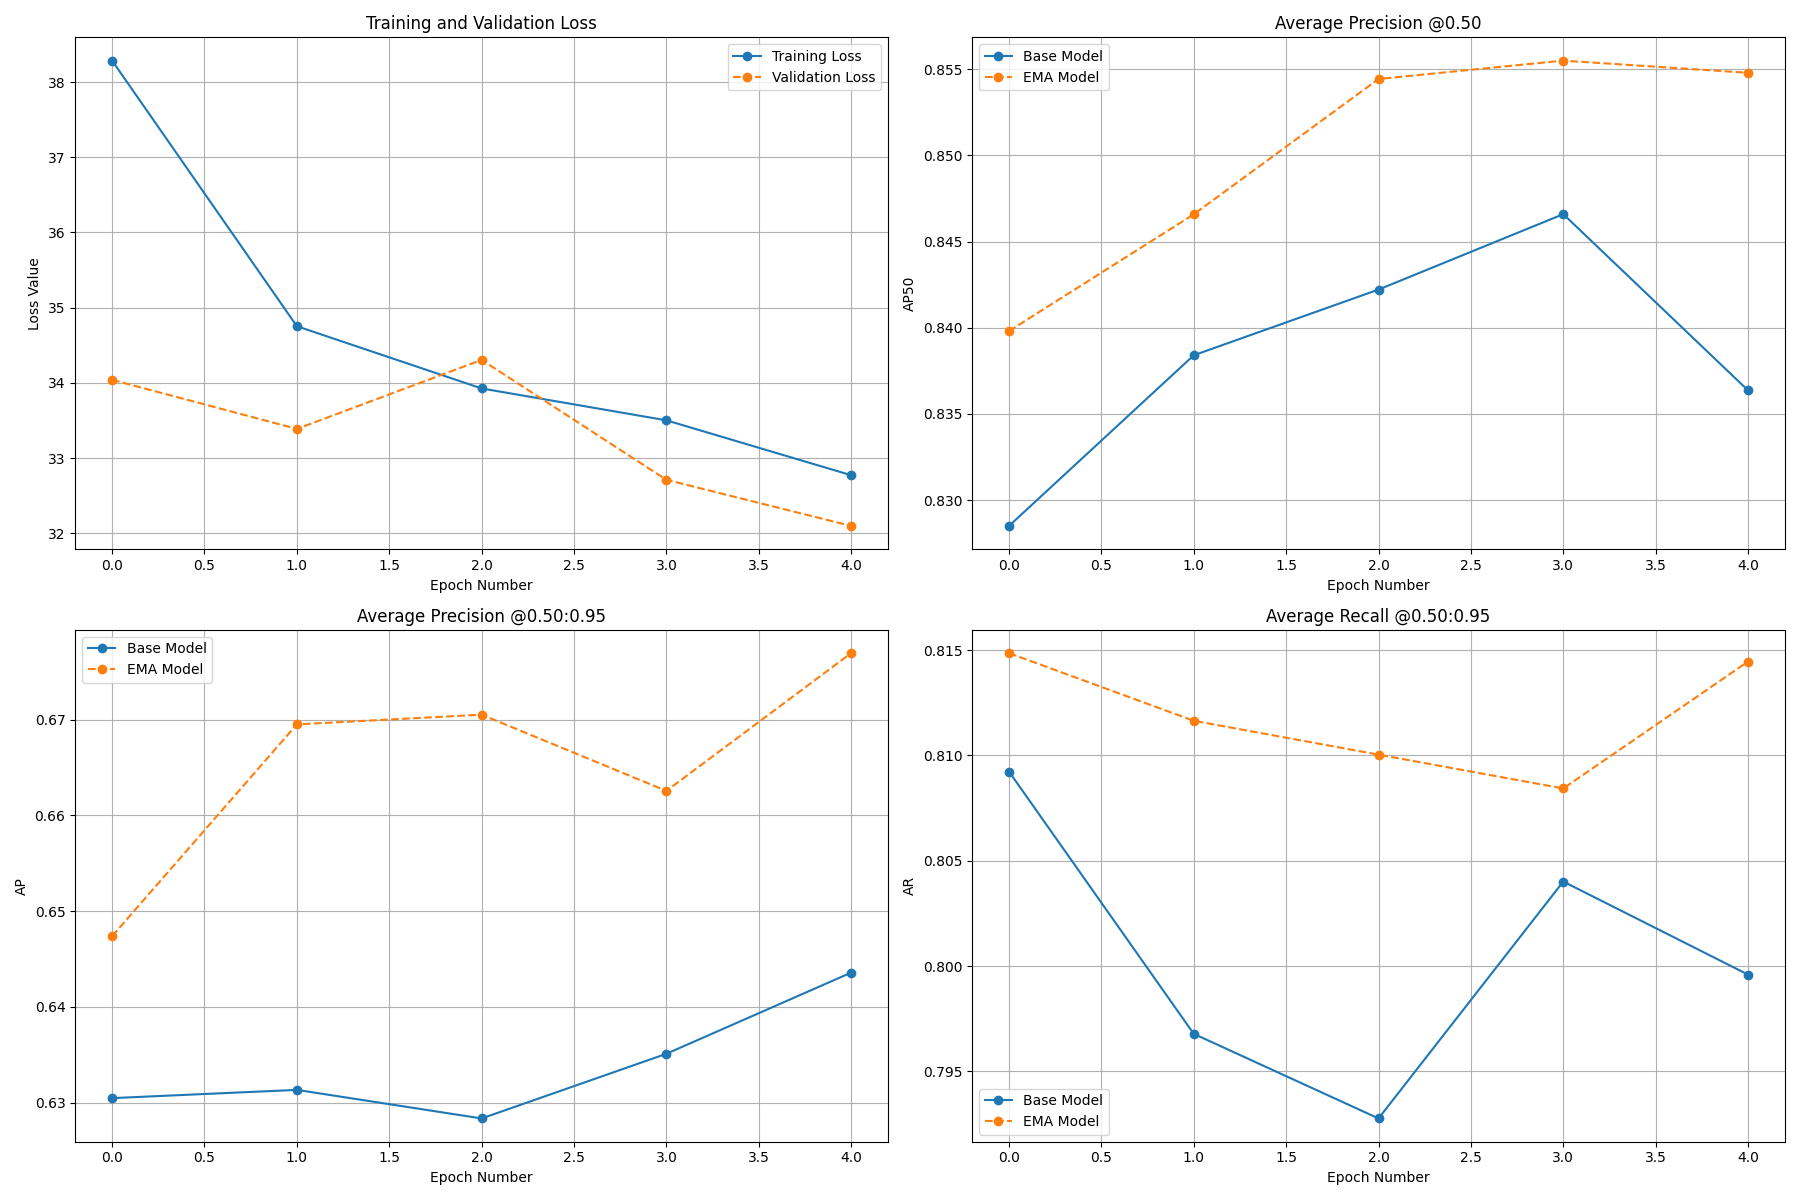

In [ ]:
from PIL import Image

Image.open("output/metrics_plot.png")

In [ ]:
!ls -la output

total 1459268
drwxr-xr-x 3 root root      4096 Oct  3 14:13 .
drwxr-xr-x 1 root root      4096 Oct  3 13:29 ..
-rw-r--r-- 1 root root 406786558 Oct  3 13:46 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 408075722 Oct  3 13:37 checkpoint_best_regular.pth
-rw-r--r-- 1 root root 135558291 Oct  3 14:13 checkpoint_best_total.pth
-rw-r--r-- 1 root root 543604707 Oct  3 14:11 checkpoint.pth
drwxr-xr-x 2 root root      4096 Oct  3 13:38 eval
-rw-r--r-- 1 root root      2242 Oct  3 14:13 events.out.tfevents.1759498173.b6deb8db157c.669.0
-rw-r--r-- 1 root root     50906 Oct  3 14:13 log.txt
-rw-r--r-- 1 root root    174037 Oct  3 14:13 metrics_plot.png
-rw-r--r-- 1 root root       636 Oct  3 14:13 results.json


## Deploy a Trained RF-DETR Model

Deploying to Roboflow allows you to create multi-step computer vision applications that run both in the cloud and your own hardware. Please wait a moment while Roboflow indexes your model.

In [ ]:
model.deploy_to_roboflow(
  workspace="roboflow-jvuqo",
  project_id="creacks-eapny",
  version=4,
  api_key=os.environ["ROBOFLOW_API_KEY"]
)

loading Roboflow workspace...
loading Roboflow project...
View the status of your deployment at: https://app.roboflow.com/roboflow-jvuqo/creacks-eapny/4
Share your model with the world at: https://universe.roboflow.com/roboflow-jvuqo/creacks-eapny/model/4


## Evaluate Fine-tuned RF-DETR Model

Before benchmarking the model, we need to load the best saved checkpoint. To ensure it fits on the GPU, we first need to free up GPU memory. This involves deleting any remaining references to previously used objects, triggering Python’s garbage collector, and clearing the CUDA memory cache.

In [ ]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [ ]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 151.07 MB | Reserved: 20684.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 151.07 MB | Reserved: 248.00 MB


We load the best-performing model from the `checkpoint_best_total.pth` file using the `RFDETRSegPreview` class. This checkpoint contains the trained weights from our most successful training run. After loading, we call `optimize_for_inference()`, which prepares the model for efficient inference.

In [ ]:
model = RFDETRSegPreview(pretrain_weights="output/checkpoint_best_total.pth")
model.optimize_for_inference()

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


## Run Inference with Fine-tuned RF-DETR Model

In [ ]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
    force_masks=True
)

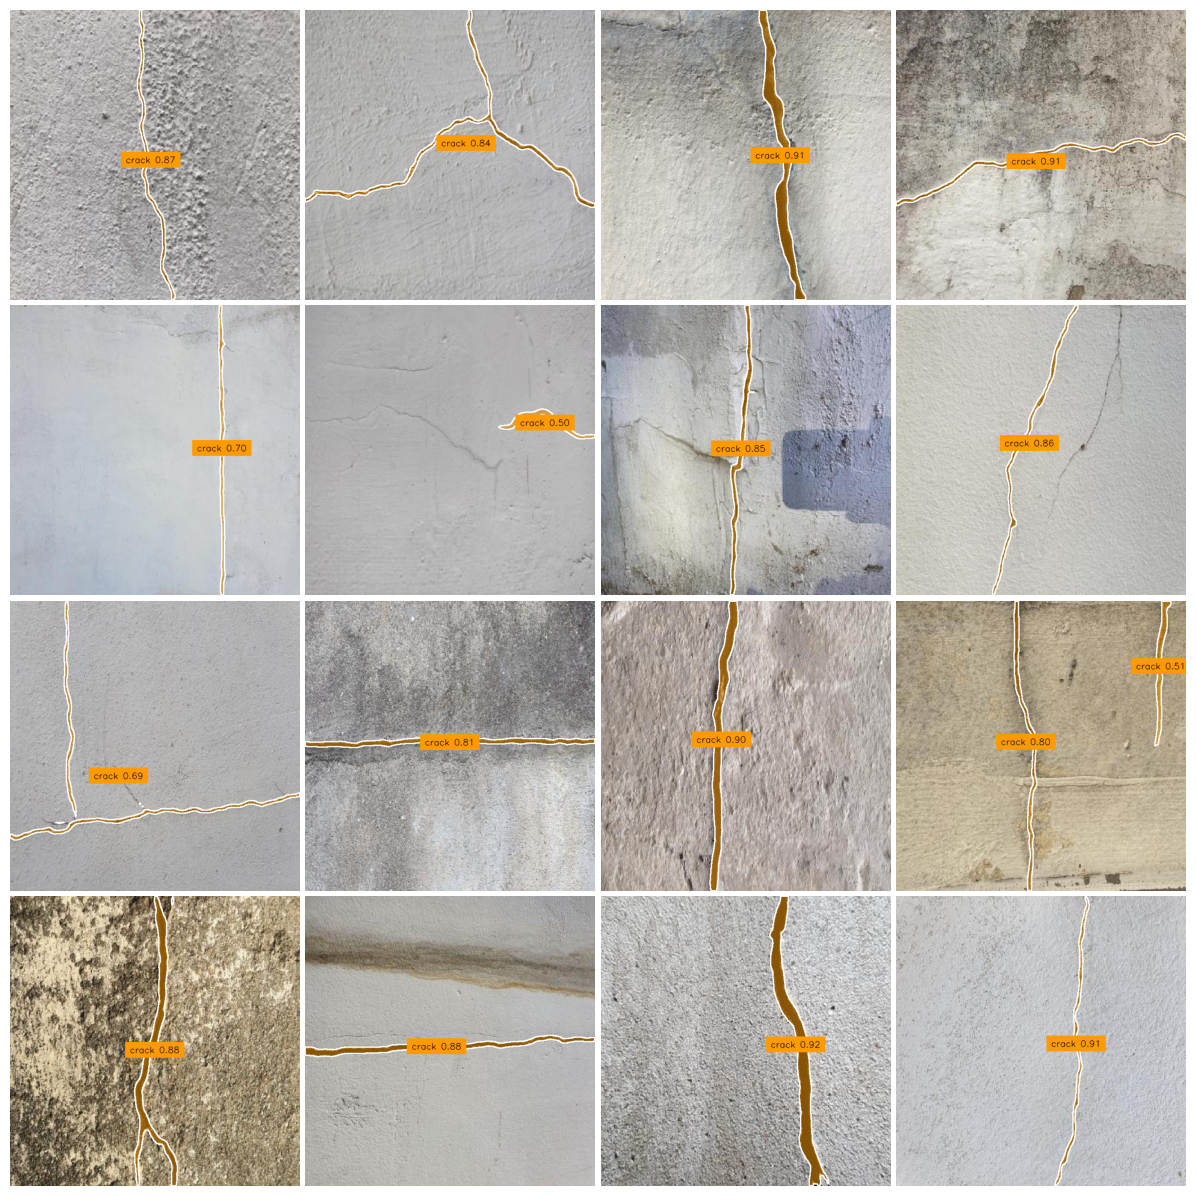

In [ ]:
import random
import matplotlib.pyplot as plt

N = 16
L = len(ds)

annotated_images = []

for i in random.sample(range(L), N):
    path, _, annotations = ds[i]
    image = Image.open(path)
    detections = model.predict(image, threshold=0.5)
    annotated_image = annotate(image, detections, classes={i: class_name for i, class_name in enumerate(ds.classes)})
    annotated_images.append(annotated_image)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, img in zip(axes.flat, annotated_images):
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)

plt.show()

In [ ]:
# Since end of Jul 2026, inference clashes with Google Colab environment regarding torchaudio. If you experience a problem with imports, 
# we suggest uninstalling torchaudio package and restarting the runtime.
!pip uninstall -y torchaudio

!pip install -q inference-gpu==0.58.1

In [ ]:
from inference import get_model

MODEL_ID = "creacks-eapny/4"
model_rf = get_model(model_id=MODEL_ID, api_key=os.environ["ROBOFLOW_API_KEY"])

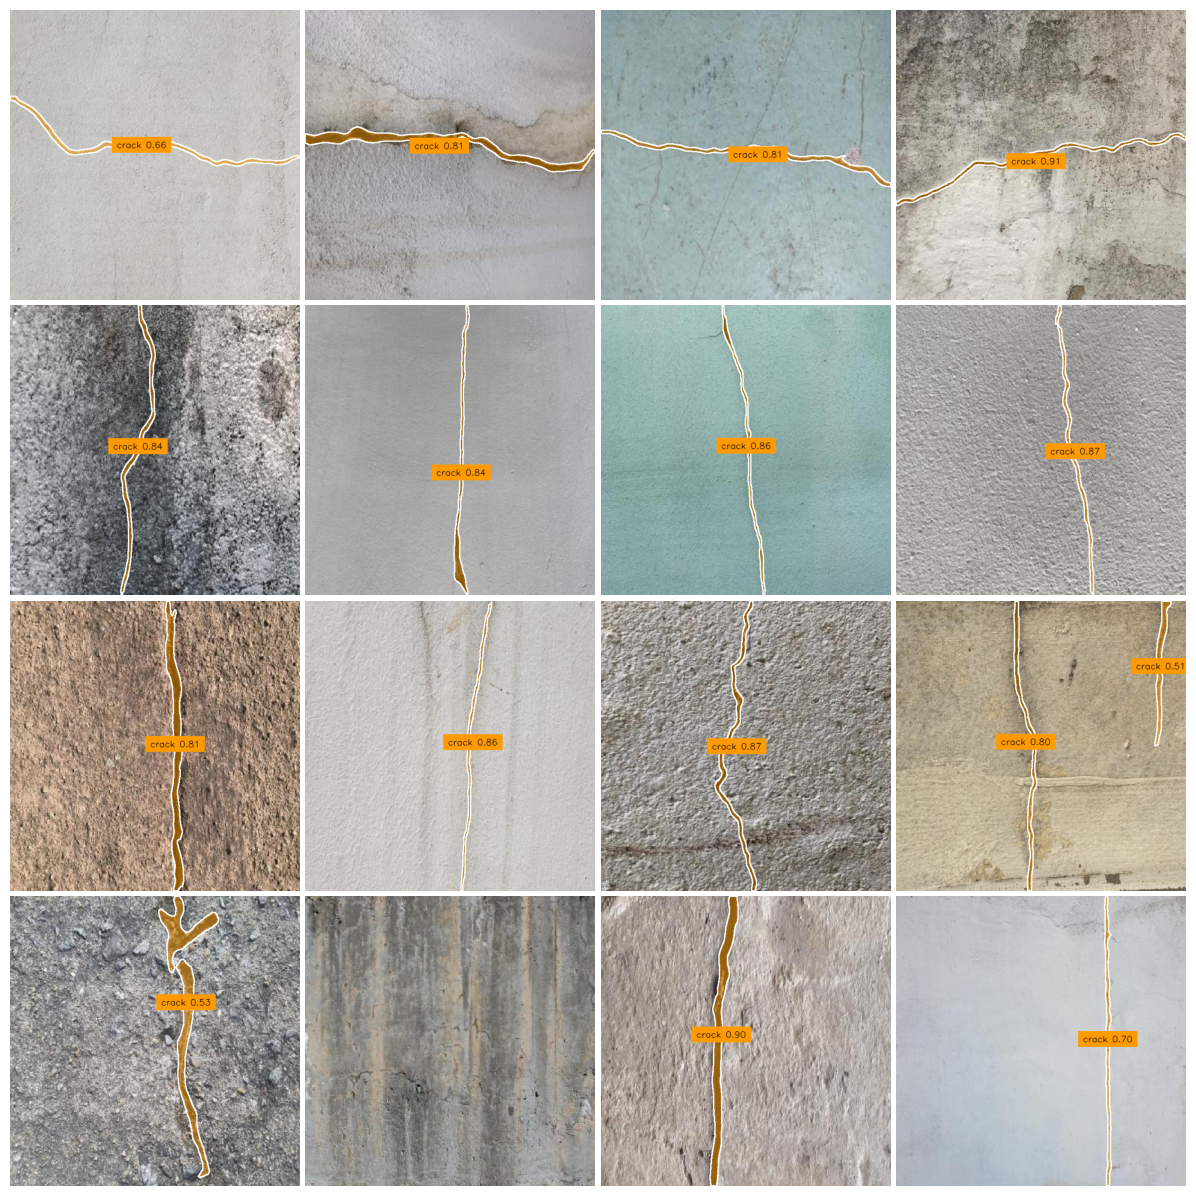

In [ ]:
import random
import matplotlib.pyplot as plt

N = 16
L = len(ds)

annotated_images = []

for i in random.sample(range(L), N):
    path, _, annotations = ds[i]
    image = Image.open(path)
    result = model_rf.infer(image, confidence=0.5)[0]
    detections = sv.Detections.from_inference(result)
    annotated_image = annotate(image, detections, classes={i: class_name for i, class_name in enumerate(ds.classes)})
    annotated_images.append(annotated_image)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, img in zip(axes.flat, annotated_images):
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)

plt.show()

<div align="center">
  <p>
    Looking for more tutorials or have questions?
    Check out our <a href="https://github.com/roboflow/notebooks">GitHub repo</a> for more notebooks,
    or visit our <a href="https://discord.gg/GbfgXGJ8Bk">discord</a>.
  </p>
  
  <p>
    <strong>If you found this helpful, please consider giving us a ⭐
    <a href="https://github.com/roboflow/notebooks">on GitHub</a>!</strong>
  </p>

</div>